# Qubits, Gates, and Quantum Sensing
### A working model for electrical and computer engineers

**What this notebook does.** It builds the core ideas of quantum computing and
quantum sensing out of three things an engineer already owns: complex amplitudes,
phase, and truth tables. Every claim is checked numerically in the cell that makes it.

The one sentence the whole notebook unpacks:

> A qubit is a phasor you are allowed to rotate but not to read.

**Learning objectives.** After working through this notebook you should be able to

1. write a qubit as a normalized pair of complex amplitudes and place it on the Bloch sphere,
2. explain why every quantum gate is a rotation, and why that rules out a two-in one-out `AND`,
3. recognize the circuit `H · Rz(φ) · H` as a Mach-Zehnder interferometer,
4. compute a reduced density matrix and use the shrinking Bloch vector as a measure of entanglement,
5. trace Grover's algorithm on four items and say exactly where the speedup comes from,
6. derive the optimal interrogation time of a Ramsey magnetometer and explain the standard quantum limit.

**Prerequisites.** Linear algebra with complex numbers, at the level of a signals and systems course.
Some familiarity with phasors, polarization, or interferometry helps but is not required.
No prior quantum mechanics is assumed.

**Companion.** An interactive browser version of the same material is available as a web module.
This notebook is the version you can modify.

### Required packages

In [ ]:
# Shared MatSciEd scaffolding: inline questions, colour palette, plot defaults.
# Pinned to a tag so this notebook keeps working if matscied-tools changes later.
try:
    import notebook_utils  # noqa: F401
except ImportError:
    %pip install -q "matscied-tools @ git+https://github.com/MatSciEd/matscied-tools.git@v0.1.0"


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers the 3d projection)

# House palette and plot defaults, with a local fallback so the notebook runs
# anywhere (offline, on a laptop without the shared package, or in Colab).
try:
    from notebook_utils import apply_plot_defaults, COLOR_DOWN
    apply_plot_defaults()
    BLUE = COLOR_DOWN
except ImportError:
    BLUE = "#1F4287"
    plt.rcParams.update({"axes.grid": False, "figure.dpi": 100,
                         "axes.spines.top": False, "axes.spines.right": False,
                         "font.size": 10})

RED, INK, GREY, VIOLET = "#A0392E", "#1a1a1a", "#8a8a8a", "#6B4C9A"

np.set_printoptions(precision=4, suppress=True, linewidth=110)
print("numpy", np.__version__, "| matplotlib", plt.matplotlib.__version__)

numpy 2.4.4 | matplotlib 3.10.9


---
## 1. The bit, and the cost of forgetting

A classical gate is a lookup table on switches. The property that is easy to miss,
because it is so familiar, is that **most classical gates destroy information**.

An `AND` gate takes two bits in and returns one bit out. If the output is 0 you cannot
say which of three inputs produced it. Count how much is lost with Shannon entropy.
Assume the inputs are uniform, so $H_{\rm in} = n$ bits, and compare against the entropy
of the output distribution.

$$\text{bits erased} = H_{\rm in} - H_{\rm out}, \qquad Q_{\min} = (\text{bits erased})\, k_B T \ln 2$$

The second expression is Landauer's principle. It is the minimum heat that must leave
the machine when information is discarded.

In [2]:
from itertools import product

KT_LN2 = 1.380649e-23 * 300.0 * np.log(2)   # joules per bit erased, at 300 K

GATES_CLASSICAL = {
    "AND":   (2, lambda a, b: (a & b,)),
    "OR":    (2, lambda a, b: (a | b,)),
    "XOR":   (2, lambda a, b: (a ^ b,)),
    "NAND":  (2, lambda a, b: (1 - (a & b),)),
    "NOT":   (1, lambda a:    (1 - a,)),
    "CNOT":  (2, lambda a, b: (a, a ^ b)),
}

def erased_bits(n_in, func):
    """Shannon entropy lost by a deterministic gate with uniform inputs."""
    counts = {}
    for bits in product((0, 1), repeat=n_in):
        out = func(*bits)
        counts[out] = counts.get(out, 0) + 1
    total = 2 ** n_in
    h_out = -sum((c / total) * np.log2(c / total) for c in counts.values())
    return n_in - h_out

print(f"{'gate':6s} {'in':>3s} {'out':>4s} {'erased (bits)':>14s} {'heat floor at 300 K':>22s}   reversible")
print("-" * 76)
for name, (n_in, func) in GATES_CLASSICAL.items():
    n_out = len(func(*([0] * n_in)))
    e = erased_bits(n_in, func)
    print(f"{name:6s} {n_in:3d} {n_out:4d} {e:14.3f} {e * KT_LN2 * 1e21:19.2f} zJ   "
          f"{'yes' if e < 1e-12 else 'no'}")

print("\nkT ln2 at 300 K = %.3e J = %.2f meV" % (KT_LN2, KT_LN2 / 1.602176634e-19 * 1000))
print("Real CMOS burns roughly a million times this per switching event,")
print("so Landauer is not yet an engineering constraint. It is a clue:")
print("irreversibility is a physical act, not a bookkeeping convenience.")

gate    in  out  erased (bits)    heat floor at 300 K   reversible
----------------------------------------------------------------------------
AND      2    1          1.189                3.41 zJ   no
OR       2    1          1.189                3.41 zJ   no
XOR      2    1          1.000                2.87 zJ   no
NAND     2    1          1.189                3.41 zJ   no
NOT      1    1          0.000                0.00 zJ   yes
CNOT     2    2          0.000                0.00 zJ   yes

kT ln2 at 300 K = 2.871e-21 J = 17.92 meV
Real CMOS burns roughly a million times this per switching event,
so Landauer is not yet an engineering constraint. It is a clue:
irreversibility is a physical act, not a bookkeeping convenience.


> #### &#128221; Check your understanding 1
> `NAND` erases the same number of bits as `AND`, yet `NAND` alone is universal for
> classical logic while `AND` alone is not. Does universality have anything to do with
> information erasure?
>
> <details><summary>Answer</summary>
>
> No. Universality is about which functions you can compose, and erasure is about how
> much of the input survives. They are independent. The relevant point for what follows
> is the last column: only `NOT` and `CNOT` erase nothing, and only gates in that column
> have a direct quantum counterpart.
> </details>

---
## 2. A qubit is a normalized phasor pair

Take a plane wave travelling toward you. Its electric field has a horizontal and a vertical
component, and each carries an amplitude and a phase, so each is a complex number. Stack them.

That is a qubit. Rename the horizontal component $\alpha$ and the vertical one $\beta$.

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle, \qquad |\alpha|^2 + |\beta|^2 = 1$$

Two complex numbers is four real numbers. Normalization removes one. Global phase is
unobservable, exactly as the choice of time origin for a phasor is unobservable, so that
removes another. Two real parameters left, which is the surface of a sphere.

$$|\psi\rangle = \cos(\theta/2)\,|0\rangle + e^{i\phi}\sin(\theta/2)\,|1\rangle$$

**Latitude sets the odds. Longitude sets the phase.** Measurement is blind to $\phi$,
and yet $\phi$ is where every quantum advantage comes from.

In [3]:
def state(theta, phi):
    """Pure single-qubit state from polar angle theta and azimuth phi."""
    return np.array([np.cos(theta / 2), np.exp(1j * phi) * np.sin(theta / 2)])

def bloch(psi):
    """Bloch vector r = (<X>, <Y>, <Z>) of a normalized state vector."""
    a, b = psi
    return np.array([2 * (a.conjugate() * b).real,
                     2 * (a.conjugate() * b).imag,
                     abs(a) ** 2 - abs(b) ** 2])

# The parameterisation and the Bloch vector must agree for every angle.
rng = np.random.default_rng(0)
worst = 0.0
for th, ph in rng.uniform([0, 0], [np.pi, 2 * np.pi], size=(2000, 2)):
    expect = np.array([np.sin(th) * np.cos(ph), np.sin(th) * np.sin(ph), np.cos(th)])
    worst = max(worst, np.abs(bloch(state(th, ph)) - expect).max())
print(f"max deviation of r from (sin0 cos1, sin0 sin1, cos0) over 2000 random states: {worst:.2e}")

for name, (th, ph) in {"|0>": (0, 0), "|1>": (np.pi, 0), "|+>": (np.pi / 2, 0),
                       "|->": (np.pi / 2, np.pi), "|i>": (np.pi / 2, np.pi / 2)}.items():
    psi = state(th, ph)
    print(f"{name:4s}  alpha={psi[0]: .3f}  beta={psi[1]: .3f}   r={bloch(psi)}")

max deviation of r from (sin0 cos1, sin0 sin1, cos0) over 2000 random states: 3.33e-16
|0>   alpha= 1.000+0.000j  beta= 0.000+0.000j   r=[0. 0. 1.]
|1>   alpha= 0.000+0.000j  beta= 1.000+0.000j   r=[ 0.  0. -1.]
|+>   alpha= 0.707+0.000j  beta= 0.707+0.000j   r=[1. 0. 0.]
|->   alpha= 0.707+0.000j  beta=-0.707+0.000j   r=[-1.  0.  0.]
|i>   alpha= 0.707+0.000j  beta= 0.000+0.707j   r=[0. 1. 0.]


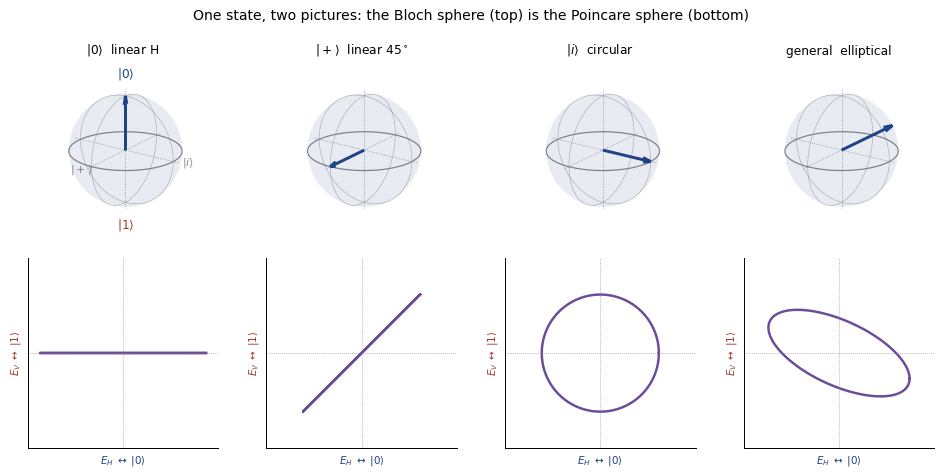

In [4]:
def bloch_axes(ax, elev=20, azim=35, labels=True):
    """Draw an empty Bloch sphere on a 3-D axis."""
    u = np.linspace(0, 2 * np.pi, 48)
    v = np.linspace(0, np.pi, 24)
    ax.plot_surface(np.outer(np.cos(u), np.sin(v)), np.outer(np.sin(u), np.sin(v)),
                    np.outer(np.ones_like(u), np.cos(v)),
                    color=BLUE, alpha=0.05, linewidth=0, shade=False)
    t = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(t), np.sin(t), 0, color=GREY, lw=1.0)                 # equator
    ax.plot(np.cos(t), np.zeros_like(t), np.sin(t), color=GREY, lw=0.5, alpha=0.6)
    ax.plot(np.zeros_like(t), np.cos(t), np.sin(t), color=GREY, lw=0.5, alpha=0.6)
    for d in np.eye(3):
        ax.plot(*np.array([-1.12 * d, 1.12 * d]).T, color=GREY, lw=0.6, ls=":")
    if labels:
        ax.text(0, 0, 1.34, r"$|0\rangle$", color=BLUE, fontsize=10, ha="center")
        ax.text(0, 0, -1.5, r"$|1\rangle$", color=RED, fontsize=10, ha="center")
        ax.text(1.3, 0, 0, r"$|+\rangle$", color=GREY, fontsize=9, ha="center")
        ax.text(0, 1.3, 0, r"$|i\rangle$", color=GREY, fontsize=9, ha="center")
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_box_aspect([1, 1, 1]); ax.set_axis_off()
    ax.view_init(elev=elev, azim=azim)

def bloch_arrow(ax, r, color=None, lw=2.4, label=None):
    """Draw one Bloch vector. Colour follows the hemisphere unless overridden."""
    r = np.asarray(r, dtype=float)
    if color is None:
        color = BLUE if r[2] >= 0 else RED
    ax.quiver(0, 0, 0, *r, color=color, lw=lw, arrow_length_ratio=0.16)
    if label:
        ax.text(*(r * 1.18), label, color=color, fontsize=9, ha="center")

def polarization(ax, theta, phi):
    """The same state drawn as the polarization ellipse of a plane wave."""
    a, b = np.cos(theta / 2), np.sin(theta / 2)
    t = np.linspace(0, 2 * np.pi, 400)
    ax.plot(a * np.cos(t), b * np.cos(t + phi), color=VIOLET, lw=2)
    ax.axhline(0, color=GREY, lw=0.6, ls=":"); ax.axvline(0, color=GREY, lw=0.6, ls=":")
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15); ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(r"$E_H \;\leftrightarrow\; |0\rangle$", fontsize=8.5, color=BLUE)
    ax.set_ylabel(r"$E_V \;\leftrightarrow\; |1\rangle$", fontsize=8.5, color=RED)

SHOWCASE = [(0.0, 0.0, r"$|0\rangle$  linear H"),
            (np.pi / 2, 0.0, r"$|+\rangle$  linear $45^\circ$"),
            (np.pi / 2, np.pi / 2, r"$|i\rangle$  circular"),
            (1.1, 2.2, r"general  elliptical")]

fig = plt.figure(figsize=(11, 5.4))
for k, (th, ph, name) in enumerate(SHOWCASE):
    ax = fig.add_subplot(2, 4, k + 1, projection="3d")
    bloch_axes(ax, labels=(k == 0))
    bloch_arrow(ax, bloch(state(th, ph)))
    ax.set_title(name, fontsize=10, pad=0)
    ax2 = fig.add_subplot(2, 4, k + 5)
    polarization(ax2, th, ph)
fig.suptitle("One state, two pictures: the Bloch sphere (top) is the Poincare sphere (bottom)",
             fontsize=11.5, y=0.99)
fig.tight_layout()
plt.show()

> #### &#128221; Check your understanding 2
> The states $|+\rangle$ and $|-\rangle$ both give a 50/50 measurement outcome. What,
> physically, distinguishes them, and what would you have to do to tell them apart?
>
> <details><summary>Answer</summary>
>
> They differ only in $\phi$, by $180^\circ$. They sit at opposite points on the equator.
> No measurement in the $|0\rangle/|1\rangle$ basis can separate them, because latitude is
> identical. To distinguish them you must first rotate the equator onto the poles, which is
> exactly what a Hadamard does. In the polarization picture they are linear light at
> $+45^\circ$ and $-45^\circ$, and you separate them with a rotated polarizer.
> </details>

In [ ]:
# Interactive version. Requires ipywidgets; the static figure above carries the argument
# if widgets are not available.
try:
    from ipywidgets import interact, FloatSlider

    @interact(theta=FloatSlider(min=0, max=180, step=1, value=58, description="theta (deg)"),
              phi=FloatSlider(min=0, max=360, step=1, value=42, description="phi (deg)"))
    def _explore(theta, phi):
        th, ph = np.radians(theta), np.radians(phi)
        psi = state(th, ph)
        fig = plt.figure(figsize=(8.4, 3.6))
        ax = fig.add_subplot(1, 2, 1, projection="3d")
        bloch_axes(ax); bloch_arrow(ax, bloch(psi))
        ax2 = fig.add_subplot(1, 2, 2); polarization(ax2, th, ph)
        fig.suptitle(f"P(0) = {abs(psi[0])**2:.3f}    P(1) = {abs(psi[1])**2:.3f}"
                     f"    relative phase = {np.degrees(np.angle(psi[1])) % 360:.0f} deg",
                     fontsize=10)
        fig.tight_layout(); plt.show()
except ImportError:
    print("ipywidgets not available - the static figure above shows the same four states.")

---
## 3. Gates are rotations

A gate must preserve total probability, so it must preserve the length of the state vector.
A length preserving linear map on a sphere is a rotation. That is the whole classification
of single-qubit gates: pick an axis, pick an angle.

$$R_{\mathbf n}(\gamma) = \cos(\gamma/2)\,I - i\,\sin(\gamma/2)\,(n_x X + n_y Y + n_z Z)$$

The half angle is not a typo. A full $360^\circ$ rotation returns the state to minus itself,
and that sign is a global phase, so the two pictures stay consistent.

In [5]:
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]], dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]], dtype=complex)
H  = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
S  = np.array([[1, 0], [0, 1j]], dtype=complex)
T  = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex)

def rot(axis, gamma):
    """Rotation of the Bloch sphere by gamma about the unit axis."""
    n = np.asarray(axis, dtype=float)
    n = n / np.linalg.norm(n)
    return np.cos(gamma / 2) * I2 - 1j * np.sin(gamma / 2) * (n[0] * X + n[1] * Y + n[2] * Z)

def same_up_to_phase(A, B):
    """True if A and B differ only by a global phase."""
    idx = np.unravel_index(np.argmax(np.abs(B)), B.shape)
    return np.allclose(A, B * (A[idx] / B[idx]))

checks = [("X  = Rx(pi)",                 X, rot([1, 0, 0], np.pi)),
          ("Y  = Ry(pi)",                 Y, rot([0, 1, 0], np.pi)),
          ("Z  = Rz(pi)",                 Z, rot([0, 0, 1], np.pi)),
          ("H  = R_(x+z)/sqrt2 (pi)",     H, rot([1, 0, 1], np.pi)),
          ("S  = Rz(pi/2)",               S, rot([0, 0, 1], np.pi / 2)),
          ("T  = Rz(pi/4)",               T, rot([0, 0, 1], np.pi / 4))]
for label, A, B in checks:
    print(f"{'PASS' if same_up_to_phase(A, B) else '**FAIL**':9s} {label}")

print("\nWhere H sends the three cardinal axes:")
for label, psi in [("+z  |0>", np.array([1, 0], dtype=complex)),
                   ("+x  |+>", np.array([1, 1], dtype=complex) / np.sqrt(2)),
                   ("+y  |i>", np.array([1, 1j], dtype=complex) / np.sqrt(2))]:
    print(f"   {label}  ->  {bloch(H @ psi)}")
print("\nH swaps the x and z axes and flips y. That is a half turn about the tilted")
print("axis halfway between them, which is why H carries a pole onto the equator.")

PASS      X  = Rx(pi)
PASS      Y  = Ry(pi)
PASS      Z  = Rz(pi)
PASS      H  = R_(x+z)/sqrt2 (pi)
PASS      S  = Rz(pi/2)
PASS      T  = Rz(pi/4)

Where H sends the three cardinal axes:
   +z  |0>  ->  [1. 0. 0.]
   +x  |+>  ->  [0. 0. 1.]
   +y  |i>  ->  [ 0. -1.  0.]

H swaps the x and z axes and flips y. That is a half turn about the tilted
axis halfway between them, which is why H carries a pole onto the equator.


H Z H |0> = [0.+0.j 1.+0.j]   which is |1>, with probability 1.0
The Z in the middle never changed a probability. It changed a phase,
and the second H converted that phase into a certainty.


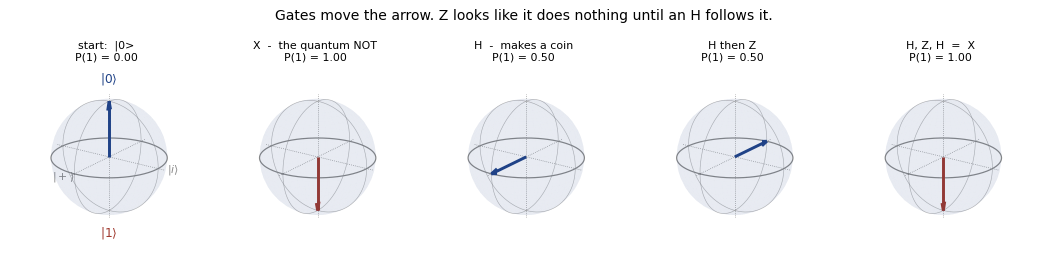

In [6]:
SEQUENCES = [("start:  |0>",          []),
             ("X  -  the quantum NOT", [("X", X)]),
             ("H  -  makes a coin",    [("H", H)]),
             ("H then Z",              [("H", H), ("Z", Z)]),
             ("H, Z, H  =  X",         [("H", H), ("Z", Z), ("H", H)])]

fig = plt.figure(figsize=(12, 2.9))
for k, (title, seq) in enumerate(SEQUENCES):
    ax = fig.add_subplot(1, 5, k + 1, projection="3d")
    bloch_axes(ax, labels=(k == 0))
    psi = np.array([1, 0], dtype=complex)
    for _, G in seq:
        psi = G @ psi
    bloch_arrow(ax, bloch(psi))
    p1 = abs(psi[1]) ** 2
    ax.set_title(f"{title}\nP(1) = {p1:.2f}", fontsize=9, pad=-2)
fig.suptitle("Gates move the arrow. Z looks like it does nothing until an H follows it.",
             fontsize=11.5, y=1.04)
fig.tight_layout()
plt.show()

psi_hz = H @ (Z @ (H @ np.array([1, 0], dtype=complex)))
print("H Z H |0> =", np.round(psi_hz, 6), "  which is |1>, with probability", round(abs(psi_hz[1])**2, 12))
print("The Z in the middle never changed a probability. It changed a phase,")
print("and the second H converted that phase into a certainty.")

> #### &#128221; Check your understanding 3
> `Z` leaves both `P(0)` and `P(1)` untouched for *every* input state. Why then is it not
> the identity gate?
>
> <details><summary>Answer</summary>
>
> `Z` is a half turn about the vertical axis. It preserves latitude, which is what fixes the
> probabilities, but it adds $180^\circ$ of longitude. Any state on the equator is moved to
> the opposite side. The change is invisible to a measurement in the $|0\rangle/|1\rangle$
> basis and completely visible after a Hadamard, as the last panel above shows.
> </details>

---
## 4. Interference, or the Mach-Zehnder you already built

Split a signal into two arms with a 3 dB coupler. Delay one arm. Recombine with a second
coupler. Which detector lights up depends entirely on the relative phase between the arms.

Now replace the two arms with the two states of one qubit. The first `H` is the input
coupler, `Rz(φ)` is the phase shifter, the second `H` is the output coupler, and the
measurement is the detector.

$$P(1) = \sin^2(\phi/2) = \tfrac{1}{2}\left(1 - \cos\phi\right)$$

This single result is the engine of both halves of the field. Quantum computing arranges
$\phi$ so that wrong answers cancel. Quantum sensing lets the world set $\phi$ and reads it
off the fringe.

max |P(1) - sin^2(phi/2)| over the sweep: 4.44e-16

H Z H equals X exactly: True


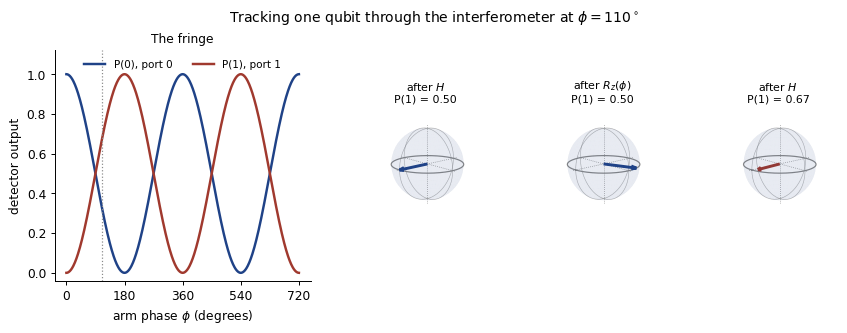

In [7]:
def interferometer(phi, stage=2):
    """State after the Mach-Zehnder, stage 0 = after first H, 1 = after phase, 2 = after second H."""
    psi = H @ np.array([1, 0], dtype=complex)
    if stage >= 1:
        psi = rot([0, 0, 1], phi) @ psi
    if stage >= 2:
        psi = H @ psi
    return psi

phis = np.linspace(0, 4 * np.pi, 601)
p1 = np.array([abs(interferometer(p)[1]) ** 2 for p in phis])
print("max |P(1) - sin^2(phi/2)| over the sweep:",
      f"{np.abs(p1 - np.sin(phis / 2) ** 2).max():.2e}")

fig = plt.figure(figsize=(11.5, 3.4))
gs = fig.add_gridspec(1, 4, width_ratios=[2.1, 1, 1, 1], wspace=0.35)

ax = fig.add_subplot(gs[0, 0])
ax.plot(np.degrees(phis), 1 - p1, color=BLUE, lw=2, label="P(0), port 0")
ax.plot(np.degrees(phis), p1, color=RED, lw=2, label="P(1), port 1")
ax.axvline(110, color=GREY, lw=1, ls=":")
ax.set_xlabel(r"arm phase $\phi$ (degrees)"); ax.set_ylabel("detector output")
ax.set_xticks([0, 180, 360, 540, 720]); ax.set_ylim(-0.04, 1.12)
ax.legend(frameon=False, fontsize=8.5, ncol=2, loc="upper center")
ax.set_title("The fringe", fontsize=10)

for k, (stg, name) in enumerate([(0, r"after $H$"), (1, r"after $R_z(\phi)$"), (2, r"after $H$")]):
    psi_stage = interferometer(np.radians(110), stg)
    sub = fig.add_subplot(gs[0, k + 1], projection="3d")
    bloch_axes(sub, labels=False, elev=14, azim=48)
    bloch_arrow(sub, bloch(psi_stage))
    sub.set_title(f"{name}\nP(1) = {abs(psi_stage[1]) ** 2:.2f}", fontsize=9, pad=-6)
fig.suptitle(r"Tracking one qubit through the interferometer at $\phi = 110^\circ$",
             fontsize=11.5, y=1.02)
plt.show()

print("\nH Z H equals X exactly:", np.allclose(H @ Z @ H, X))

> #### &#128221; Check your understanding 4
> In the middle panel the arrow has moved but `P(1)` has not changed. Where is the
> information about $\phi$ being stored at that moment, and what does the second `H` do to it?
>
> <details><summary>Answer</summary>
>
> It is stored in the longitude, that is in the relative phase between $\alpha$ and $\beta$.
> A measurement reads latitude, so at that moment the phase is genuinely unreadable. The
> second `H` rotates the equator onto the polar axis, which converts longitude into latitude.
> Only then is the phase something a detector can see. Every quantum algorithm and every
> quantum sensor ends with a step that does this.
> </details>

---
## 5. Where did AND and OR go?

A rotation can always be undone, so every quantum gate is invertible, and an invertible map
needs as many outputs as inputs. A two in, one out `AND` cannot be a rotation of anything.

The fix is old and classical. Keep the inputs and write the answer onto a spare wire.
`CNOT` does this for `XOR`. The **Toffoli** gate, a doubly controlled `NOT`, does it for `AND`.

Because `NAND` is universal and Toffoli gives you `NAND` for free, every classical circuit
can be run on a quantum computer.

In [8]:
CNOT = np.array([[1, 0, 0, 0],
                 [0, 1, 0, 0],
                 [0, 0, 0, 1],
                 [0, 0, 1, 0]], dtype=complex)

TOFFOLI = np.eye(8, dtype=complex)
TOFFOLI[[6, 7]] = TOFFOLI[[7, 6]]        # |110> <-> |111>

print("Toffoli:  a b c   ->   a' b' c'     what the third wire reads")
print("-" * 58)
for a, b, c in [(x >> 2 & 1, x >> 1 & 1, x & 1) for x in range(8)]:
    out = int(np.argmax(np.abs(TOFFOLI @ np.eye(8)[(a << 2) | (b << 1) | c])))
    ap, bp, cp = out >> 2 & 1, out >> 1 & 1, out & 1
    note = f"a AND  b = {a & b}" if c == 0 else f"a NAND b = {1 - (a & b)}"
    print(f"          {a} {b} {c}   ->   {ap} {bp} {cp}      {note}")

print("\nToffoli is its own inverse:", np.allclose(TOFFOLI @ TOFFOLI, np.eye(8)))
print("CNOT    is its own inverse:", np.allclose(CNOT @ CNOT, np.eye(4)))
print("Both are unitary:          ",
      np.allclose(TOFFOLI.conj().T @ TOFFOLI, np.eye(8)) and
      np.allclose(CNOT.conj().T @ CNOT, np.eye(4)))
print("\nSet the third wire to 0 and it reads out a AND b while a and b survive.")
print("Set it to 1 and it reads out a NAND b. NAND is universal, so nothing classical is lost.")

Toffoli:  a b c   ->   a' b' c'     what the third wire reads
----------------------------------------------------------
          0 0 0   ->   0 0 0      a AND  b = 0
          0 0 1   ->   0 0 1      a NAND b = 1
          0 1 0   ->   0 1 0      a AND  b = 0
          0 1 1   ->   0 1 1      a NAND b = 1
          1 0 0   ->   1 0 0      a AND  b = 0
          1 0 1   ->   1 0 1      a NAND b = 1
          1 1 0   ->   1 1 1      a AND  b = 1
          1 1 1   ->   1 1 0      a NAND b = 0

Toffoli is its own inverse: True
CNOT    is its own inverse: True
Both are unitary:           True

Set the third wire to 0 and it reads out a AND b while a and b survive.
Set it to 1 and it reads out a NAND b. NAND is universal, so nothing classical is lost.


> #### &#128221; Check your understanding 5
> Making a circuit reversible costs extra wires holding intermediate results. Why can a
> quantum algorithm not simply leave those wires lying around?
>
> <details><summary>Answer</summary>
>
> Because a leftover wire that is correlated with the computation is entangled with it. As
> section 6 shows, entanglement shrinks the Bloch vector of the part you care about, which
> destroys the interference the algorithm depends on. The standard remedy is to copy the
> answer onto a fresh wire and then run the circuit backwards to clear the scratch space.
> This is called uncomputation and it is an unavoidable part of quantum algorithm design.
> </details>

---
## 6. Two qubits, and the arrows disappear

Two bits have four possible values. Two qubits carry four complex amplitudes, one per value.
Ten qubits carry 1024, and fifty carry more than a quadrillion.

The trap is to read those amplitudes as a warehouse of parallel answers. They are not.
**Measuring $n$ qubits returns exactly $n$ bits.** The amplitudes are an internal ledger,
and the only way to profit is to make the unwanted entries cancel.

Now the strange part. Run `H` on the first qubit, then `CNOT` onto the second. The pair is
in a perfectly definite state, and yet each qubit on its own has no direction at all.

In [9]:
def partial_trace(psi4, keep):
    """Reduced density matrix of one qubit of a two-qubit pure state."""
    M = psi4.reshape(2, 2)                      # index [qubit A, qubit B]
    return M @ M.conj().T if keep == 0 else M.T @ M.conj()

def bloch_of_rho(rho):
    return np.array([2 * rho[0, 1].real, -2 * rho[0, 1].imag,
                     (rho[0, 0] - rho[1, 1]).real])

def concurrence(psi4):
    """Entanglement measure for a two-qubit pure state. 0 = separable, 1 = maximal."""
    return 2 * abs(psi4[0] * psi4[3] - psi4[1] * psi4[2])

ket00 = np.zeros(4, dtype=complex); ket00[0] = 1
product_state = np.kron(H, I2) @ ket00                 # H on A only
bell_state    = CNOT @ np.kron(H, I2) @ ket00          # then CNOT

for name, psi in [("product  (H on A)", product_state), ("Bell  (H then CNOT)", bell_state)]:
    rA, rB = bloch_of_rho(partial_trace(psi, 0)), bloch_of_rho(partial_trace(psi, 1))
    pur = np.trace(partial_trace(psi, 0) @ partial_trace(psi, 0)).real
    print(f"{name:22s} amplitudes = {psi.real}")
    print(f"{'':22s} |r_A| = {np.linalg.norm(rA):.3f}   |r_B| = {np.linalg.norm(rB):.3f}"
          f"   purity of A = {pur:.3f}   concurrence = {concurrence(psi):.3f}")
print("\nThe pair is pure in both cases. Only the parts lost their direction.")

product  (H on A)      amplitudes = [0.7071 0.     0.7071 0.    ]
                       |r_A| = 1.000   |r_B| = 1.000   purity of A = 1.000   concurrence = 0.000
Bell  (H then CNOT)    amplitudes = [0.7071 0.     0.     0.7071]
                       |r_A| = 0.000   |r_B| = 0.000   purity of A = 0.500   concurrence = 1.000

The pair is pure in both cases. Only the parts lost their direction.


20000 shots on the Bell state: {'00': 9916, '01': 0, '10': 0, '11': 10084}
the two bits agreed in 100.00% of shots,
even though neither bit on its own is anything but a fair coin.


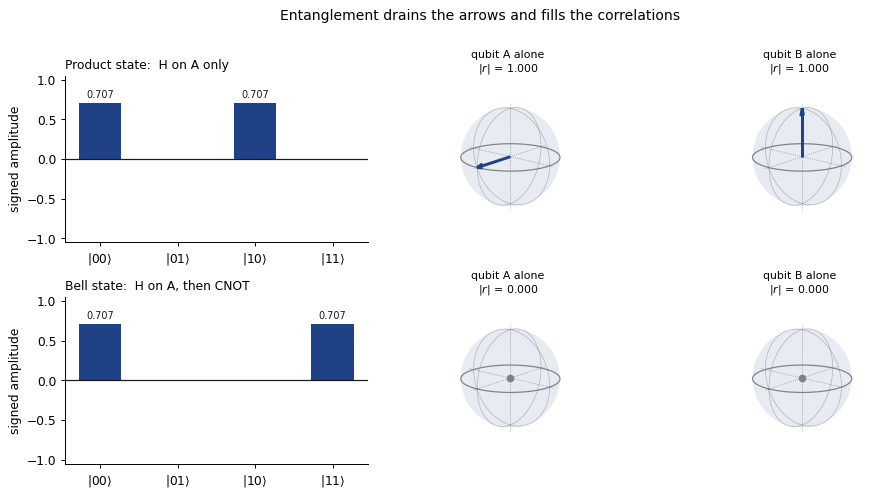

In [10]:
LABELS = [r"$|00\rangle$", r"$|01\rangle$", r"$|10\rangle$", r"$|11\rangle$"]

fig = plt.figure(figsize=(11, 5.6))
for row, (name, psi) in enumerate([("Product state:  H on A only", product_state),
                                   ("Bell state:  H on A, then CNOT", bell_state)]):
    ax = fig.add_subplot(2, 3, 3 * row + 1)
    amps = psi.real
    ax.bar(range(4), amps, color=[BLUE if v >= 0 else RED for v in amps], width=0.55)
    ax.axhline(0, color=INK, lw=1)
    ax.set_xticks(range(4)); ax.set_xticklabels(LABELS)
    ax.set_ylim(-1.05, 1.05); ax.set_ylabel("signed amplitude")
    ax.set_title(name, fontsize=10, loc="left")
    for k, v in enumerate(amps):
        if abs(v) > 1e-9:
            ax.text(k, v + 0.07 * np.sign(v), f"{v:.3f}", ha="center", fontsize=8, color=INK)

    for col, q in enumerate("AB"):
        sub = fig.add_subplot(2, 3, 3 * row + 2 + col, projection="3d")
        bloch_axes(sub, labels=False, elev=16, azim=40)
        r = bloch_of_rho(partial_trace(psi, col))
        L = np.linalg.norm(r)
        if L > 1e-6:
            bloch_arrow(sub, r)
        else:
            sub.scatter([0], [0], [0], color=GREY, s=28)
        sub.set_title(f"qubit {q} alone\n$|r|$ = {L:.3f}", fontsize=9, pad=-4)
fig.suptitle("Entanglement drains the arrows and fills the correlations", fontsize=11.5, y=1.0)
fig.tight_layout()
plt.show()

# Correlation is still perfect for the Bell state - check it by sampling.
rng = np.random.default_rng(7)
probs = np.abs(bell_state) ** 2
draws = rng.choice(4, size=20000, p=probs)
counts = np.bincount(draws, minlength=4)
print("20000 shots on the Bell state:",
      {k: int(v) for k, v in zip(["00", "01", "10", "11"], counts)})
print(f"the two bits agreed in {(counts[0] + counts[3]) / 200:.2f}% of shots,")
print("even though neither bit on its own is anything but a fair coin.")

> #### &#128221; Check your understanding 6
> A single qubit sitting in a noisy environment also ends up with a short Bloch vector.
> Is there any difference between that and half of a Bell pair?
>
> <details><summary>Answer</summary>
>
> Locally there is none, and that is the point. Decoherence *is* entanglement with the
> environment. The difference is bookkeeping: with a Bell pair you hold the other half, so
> the state of the whole is pure and the correlation is usable. With the environment you do
> not, so the information is gone for good. Section 8 turns this into the coherence time
> $T_2$.
> </details>

---
## 7. An algorithm is interference you designed on purpose

Four boxes, one prize. Classically you open boxes until you find it, which takes 2.25 tries
on average. Quantum mechanically one query suffices, and the answer is certain.

The trick has two moves.

1. The **oracle** flips the *sign* of the marked amplitude. No probability could ever do this,
   because probabilities cannot be negative. Every measurement probability is still 25 percent,
   so the information is hidden entirely in a sign.
2. The **diffusion** step reflects every amplitude about their mean. The marked entry was below
   the mean and is thrown far above it. The other three land exactly on zero. They did not
   fail. They cancelled.

marked item 0:  P(marked) = 1.000000000000   others = [0. 0. 0.]
marked item 1:  P(marked) = 1.000000000000   others = [0. 0. 0.]
marked item 2:  P(marked) = 1.000000000000   others = [0. 0. 0.]
marked item 3:  P(marked) = 1.000000000000   others = [0. 0. 0.]

Classical average for 4 boxes, checking one at a time: (1+2+3+3)/4 = 2.25 queries
Grover: 1 query, and the answer is certain rather than probable.


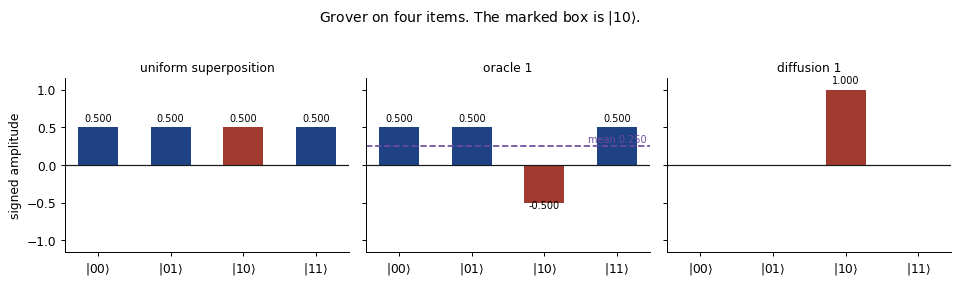

In [11]:
def grover_steps(n_items, marked, iterations):
    """Return the amplitude vector after each stage of Grover's algorithm."""
    a = np.ones(n_items) / np.sqrt(n_items)
    history = [("uniform superposition", a.copy())]
    for it in range(iterations):
        a = a.copy(); a[marked] *= -1
        history.append((f"oracle {it + 1}", a.copy()))
        a = 2 * a.mean() - a
        history.append((f"diffusion {it + 1}", a.copy()))
    return history

hist = grover_steps(4, marked=2, iterations=1)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1), sharey=True)
for ax, (name, a) in zip(axes, hist):
    ax.bar(range(4), a, width=0.55,
           color=[RED if k == 2 else BLUE for k in range(4)])
    ax.axhline(0, color=INK, lw=1)
    if "oracle" in name:
        ax.axhline(a.mean(), color=VIOLET, lw=1.4, ls="--")
        ax.text(3.4, a.mean() + 0.05, f"mean {a.mean():.3f}", color=VIOLET,
                fontsize=8, ha="right")
    ax.set_xticks(range(4)); ax.set_xticklabels(LABELS)
    ax.set_ylim(-1.15, 1.15); ax.set_title(name, fontsize=10)
    for k, v in enumerate(a):
        if abs(v) > 1e-9:
            ax.text(k, v + 0.08 * np.sign(v), f"{v:.3f}", ha="center", fontsize=8)
axes[0].set_ylabel("signed amplitude")
fig.suptitle("Grover on four items. The marked box is $|10\\rangle$.", fontsize=11.5, y=1.03)
fig.tight_layout()
plt.show()

for marked in range(4):
    final = grover_steps(4, marked, 1)[-1][1]
    print(f"marked item {marked}:  P(marked) = {final[marked] ** 2:.12f}   "
          f"others = {np.delete(final, marked) ** 2}")
print("\nClassical average for 4 boxes, checking one at a time: (1+2+3+3)/4 =",
      (1 + 2 + 3 + 3) / 4, "queries")
print("Grover:", 1, "query, and the answer is certain rather than probable.")

N =   16   optimal iterations floor(pi/4 sqrt(N)) =   3   P(success) there = 0.9613   classical average = 8 queries
N =   64   optimal iterations floor(pi/4 sqrt(N)) =   6   P(success) there = 0.9966   classical average = 32 queries
N =  256   optimal iterations floor(pi/4 sqrt(N)) =  12   P(success) there = 0.9999   classical average = 128 queries

Grover is a quadratic speedup, sqrt(N) instead of N. Shor's factoring algorithm
is exponential and uses the same idea with a Fourier-transform interference pattern.


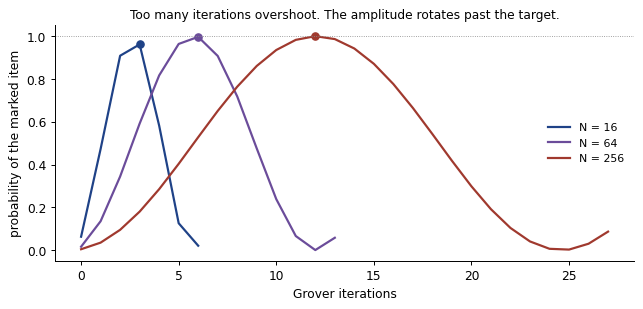

In [12]:
fig, ax = plt.subplots(figsize=(7.4, 3.6))
for N, colour in [(16, BLUE), (64, VIOLET), (256, RED)]:
    kmax = int(2.2 * np.pi / 4 * np.sqrt(N))
    hist = grover_steps(N, marked=0, iterations=kmax)
    probs = [a[0] ** 2 for name, a in hist if "diffusion" in name or name == "uniform superposition"]
    ax.plot(range(len(probs)), probs, color=colour, lw=1.8, label=f"N = {N}")
    opt = int(np.floor(np.pi / 4 * np.sqrt(N)))
    ax.plot([opt], [probs[opt]], "o", color=colour, ms=6)
    print(f"N = {N:4d}   optimal iterations floor(pi/4 sqrt(N)) = {opt:3d}   "
          f"P(success) there = {probs[opt]:.4f}   classical average = {N / 2:.0f} queries")
ax.axhline(1, color=GREY, lw=0.7, ls=":")
ax.set_xlabel("Grover iterations"); ax.set_ylabel("probability of the marked item")
ax.set_title("Too many iterations overshoot. The amplitude rotates past the target.", fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()
print("\nGrover is a quadratic speedup, sqrt(N) instead of N. Shor's factoring algorithm")
print("is exponential and uses the same idea with a Fourier-transform interference pattern.")

> #### &#128221; Check your understanding 7
> Running Grover for more iterations makes the success probability go back down. What
> geometric picture explains that?
>
> <details><summary>Answer</summary>
>
> The two steps together are a rotation by a fixed angle in the plane spanned by the marked
> state and the uniform superposition of the rest. Each iteration turns the state vector a
> little further toward the marked axis. Past the target it keeps turning and starts moving
> away, which is why the optimal count is $\lfloor(\pi/4)\sqrt{N}\rfloor$ and not "as many as
> you can afford".
> </details>

---
## 8. Quantum sensing: stop computing the phase and measure it

Put a qubit on the equator with an `H`, then leave it alone for a time $\tau$. If it has a
magnetic moment and sits in a field $B$, it precesses at the Larmor rate and accumulates phase.
A second `H` turns that phase into an outcome.

$$\phi = \gamma B \tau, \qquad P(1) = \tfrac{1}{2}\left(1 - e^{-\tau/T_2}\cos\phi\right)$$

This is a **Ramsey sequence**. It is the backbone of atomic clocks, nitrogen vacancy
magnetometers, and molecular spin qubits. The qubit is a lock-in amplifier whose reference
oscillator is itself.

Two effects fight. Longer $\tau$ accumulates more phase per unit of field. But the environment
scrambles the phase, and the fringe contrast decays as $e^{-\tau/T_2}$. Minimum detectable field
goes as

$$\delta B_{\min} \;\propto\; \frac{1}{\gamma\,\sqrt{\tau}\;e^{-\tau/T_2}}$$

and the optimum is **not** at the coherence time.

T2 = 190 ns
numerically optimal interrogation time = 95.05 ns
T2 / 2                                 = 95.00 ns
relative error of the analytic result  = 5.69e-04

The optimum sits at T2/2 for every material, so doubling T2 buys exactly
a factor sqrt(2) in sensitivity. That is why coherence time is the number
materials people chase.


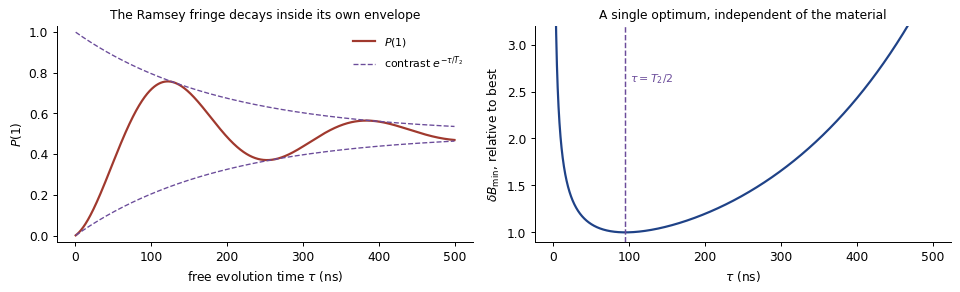

In [13]:
def ramsey(tau, omega, T2):
    return 0.5 * (1 - np.exp(-tau / T2) * np.cos(omega * tau))

def sensitivity(tau, T2):
    """Minimum detectable field, up to constants. Lower is better."""
    return 1.0 / (np.sqrt(tau) * np.exp(-tau / T2))

T2, omega = 190.0, 0.024                # ns, rad/ns
tau = np.linspace(0.5, 500, 4000)

opt = tau[np.argmin(sensitivity(tau, T2))]
print(f"T2 = {T2:.0f} ns")
print(f"numerically optimal interrogation time = {opt:.2f} ns")
print(f"T2 / 2                                 = {T2 / 2:.2f} ns")
print(f"relative error of the analytic result  = {abs(opt - T2 / 2) / (T2 / 2):.2e}")
print("\nThe optimum sits at T2/2 for every material, so doubling T2 buys exactly")
print("a factor sqrt(2) in sensitivity. That is why coherence time is the number")
print("materials people chase.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
ax = axes[0]
ax.plot(tau, ramsey(tau, omega, T2), color=RED, lw=1.8, label=r"$P(1)$")
for s in (1, -1):
    ax.plot(tau, 0.5 + s * 0.5 * np.exp(-tau / T2), color=VIOLET, lw=1.1, ls="--",
            label=r"contrast $e^{-\tau/T_2}$" if s == 1 else None)
ax.set_xlabel(r"free evolution time $\tau$ (ns)"); ax.set_ylabel(r"$P(1)$")
ax.set_ylim(-0.03, 1.03); ax.legend(frameon=False, fontsize=9, loc="upper right")
ax.set_title("The Ramsey fringe decays inside its own envelope", fontsize=10)

ax = axes[1]
ax.plot(tau, sensitivity(tau, T2) / sensitivity(opt, T2), color=BLUE, lw=1.8)
ax.axvline(opt, color=VIOLET, lw=1.2, ls="--")
ax.text(opt * 1.06, 2.6, r"$\tau = T_2/2$", color=VIOLET, fontsize=9)
ax.set_xlabel(r"$\tau$ (ns)"); ax.set_ylabel(r"$\delta B_{\min}$, relative to best")
ax.set_ylim(0.9, 3.2); ax.set_title("A single optimum, independent of the material", fontsize=10)
fig.tight_layout()
plt.show()

In [ ]:
# Interactive version.
try:
    from ipywidgets import interact, FloatSlider

    @interact(gammaB=FloatSlider(min=0.004, max=0.06, step=0.002, value=0.024,
                                 description="gamma B", readout_format=".3f"),
              T2_ns=FloatSlider(min=20, max=400, step=10, value=190, description="T2 (ns)"),
              tau_ns=FloatSlider(min=1, max=400, step=1, value=95, description="tau (ns)"))
    def _ramsey(gammaB, T2_ns, tau_ns):
        t = np.linspace(0.5, 400, 2000)
        fig, ax = plt.subplots(figsize=(7.6, 3.0))
        ax.plot(t, ramsey(t, gammaB, T2_ns), color=RED, lw=1.8)
        for s in (1, -1):
            ax.plot(t, 0.5 + s * 0.5 * np.exp(-t / T2_ns), color=VIOLET, lw=1, ls="--")
        ax.axvline(tau_ns, color=GREY, lw=1, ls=":")
        ax.plot([tau_ns], [ramsey(tau_ns, gammaB, T2_ns)], "o", color=RED, ms=7)
        ax.set_ylim(-0.03, 1.03); ax.set_xlabel(r"$\tau$ (ns)"); ax.set_ylabel("P(1)")
        rel = sensitivity(T2_ns / 2, T2_ns) / sensitivity(tau_ns, T2_ns)
        ax.set_title(f"phase = {np.degrees(gammaB * tau_ns):.0f} deg   "
                     f"contrast = {np.exp(-tau_ns / T2_ns):.3f}   "
                     f"sensitivity = {100 * rel:.1f}% of best", fontsize=10)
        fig.tight_layout(); plt.show()
except ImportError:
    print("ipywidgets not available - the static figures above carry the argument.")

> #### &#128221; Check your understanding 8
> A colleague proposes running the sensor at $\tau = 3T_2$ "to collect more phase". What is
> wrong, quantitatively?
>
> <details><summary>Answer</summary>
>
> The signal grows only as $\sqrt{\tau}$ per unit of averaging time, while the contrast falls
> as $e^{-\tau/T_2}$. At $\tau = 3T_2$ the contrast is $e^{-3} = 0.050$, so the fringe is
> almost flat. The curve on the right shows the minimum detectable field is several times
> worse than at $T_2/2$. More phase is useless if you cannot see the fringe it sits on.
> </details>

---
## 9. How good can a sensor get? Shot noise against the Heisenberg limit

Every measurement of a qubit is one coin flip. Averaging $N$ independent probes beats the
noise down as $1/\sqrt N$. Engineers call this shot noise. Here it is called the
**standard quantum limit**, and it is not a law of nature. It is the law for uncorrelated probes.

Entangle the $N$ qubits into a GHZ state, $(|00\ldots0\rangle + |11\ldots1\rangle)/\sqrt2$,
and the accumulated phase is $N\phi$ instead of $\phi$. The fringe is $N$ times finer and the
uncertainty falls as $1/N$, the **Heisenberg limit**.

Rather than assert the scaling, simulate it.

In [14]:
def ghz_relative_phase(N, phi):
    """Relative phase between the two GHZ branches after each qubit picks up phi."""
    ghz = np.zeros(2 ** N, dtype=complex); ghz[0] = ghz[-1] = 1 / np.sqrt(2)
    weights = np.array([bin(k).count("1") for k in range(2 ** N)])
    out = np.exp(1j * phi * weights) * ghz
    return np.angle(out[-1] / out[0])

for N in (2, 3, 4, 5):
    got = ghz_relative_phase(N, 0.37)
    print(f"GHZ with N = {N}:  relative phase = {got:.6f}   N * phi = {N * 0.37:.6f}   "
          f"{'PASS' if abs(got - N * 0.37) < 1e-12 else 'FAIL'}")

GHZ with N = 2:  relative phase = 0.740000   N * phi = 0.740000   PASS
GHZ with N = 3:  relative phase = 1.110000   N * phi = 1.110000   PASS
GHZ with N = 4:  relative phase = 1.480000   N * phi = 1.480000   PASS
GHZ with N = 5:  relative phase = 1.850000   N * phi = 1.850000   PASS


fitted scaling, independent probes: N^(-0.492)   theory: N^(-0.500)
fitted scaling, GHZ probes:         N^(-1.027)   theory: N^(-1.000)

advantage at N = 128: 11.3 times,   sqrt(N) = 11.3

Every point used 64 shots, so the comparison is at equal measurement time.


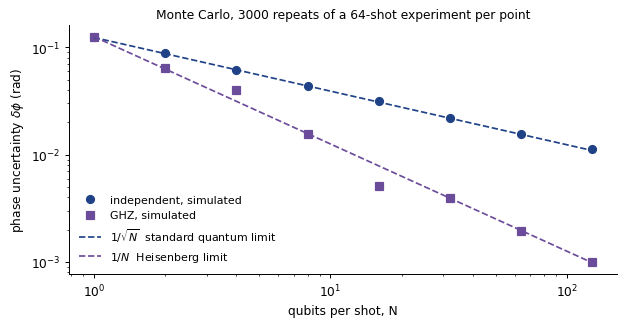

In [15]:
rng = np.random.default_rng(11)
PHI_TRUE, SHOTS, TRIALS = 0.30, 64, 3000

# Both strategies get the same number of shots. They differ only in how the N qubits
# of each shot are prepared: separately, or as one GHZ state.
def estimate_independent(N, phi):
    """Each shot measures N unentangled qubits. Biased to the steepest point of the fringe."""
    p = 0.5 * (1 + np.sin(phi))
    p_hat = rng.binomial(N * SHOTS, p) / (N * SHOTS)
    return np.arcsin(np.clip(2 * p_hat - 1, -1, 1))

def estimate_ghz(N, phi):
    """Each shot measures one GHZ state of N qubits. Its fringe oscillates N times faster."""
    p = 0.5 * (1 + np.sin(N * phi))
    p_hat = rng.binomial(SHOTS, p) / SHOTS
    return np.arcsin(np.clip(2 * p_hat - 1, -1, 1)) / N

Ns = np.array([1, 2, 4, 8, 16, 32, 64, 128])
err_ind = np.array([np.std([estimate_independent(N, PHI_TRUE) for _ in range(TRIALS)]) for N in Ns])
err_ghz = np.array([np.std([estimate_ghz(N, PHI_TRUE) for _ in range(TRIALS)]) for N in Ns])

fit = Ns >= 4      # the two smallest N are dominated by the arcsin clipping
slope_ind = np.polyfit(np.log(Ns[fit]), np.log(err_ind[fit]), 1)[0]
slope_ghz = np.polyfit(np.log(Ns[fit]), np.log(err_ghz[fit]), 1)[0]
print(f"fitted scaling, independent probes: N^({slope_ind:+.3f})   theory: N^(-0.500)")
print(f"fitted scaling, GHZ probes:         N^({slope_ghz:+.3f})   theory: N^(-1.000)")
print(f"\nadvantage at N = {Ns[-1]}: {err_ind[-1] / err_ghz[-1]:.1f} times,"
      f"   sqrt(N) = {np.sqrt(Ns[-1]):.1f}")
print(f"\nEvery point used {SHOTS} shots, so the comparison is at equal measurement time.")

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.loglog(Ns, err_ind, "o", color=BLUE, ms=6.5, label="independent, simulated")
ax.loglog(Ns, err_ghz, "s", color=VIOLET, ms=6, label="GHZ, simulated")
ax.loglog(Ns, err_ind[0] / np.sqrt(Ns), color=BLUE, lw=1.4, ls="--",
          label=r"$1/\sqrt{N}$  standard quantum limit")
ax.loglog(Ns, err_ghz[0] / Ns, color=VIOLET, lw=1.4, ls="--",
          label=r"$1/N$  Heisenberg limit")
ax.set_xlabel("qubits per shot, N"); ax.set_ylabel(r"phase uncertainty $\delta\phi$ (rad)")
ax.set_title(f"Monte Carlo, {TRIALS} repeats of a {SHOTS}-shot experiment per point",
             fontsize=10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

> #### &#128221; Check your understanding 9
> The simulation above has no noise in it. A GHZ state of $N$ qubits dephases roughly $N$
> times faster than a single qubit. What does that do to the advantage?
>
> <details><summary>Answer</summary>
>
> It removes the better *scaling*. With uncorrelated dephasing the GHZ state must be
> interrogated for a time $\tau/N$ to keep the same contrast, which costs a factor $\sqrt N$
> and leaves a constant-factor gain rather than a $\sqrt N$ one. This is why most deployed
> quantum sensors run at the standard quantum limit and win by having a very large $\gamma$,
> not by entangling anything. Exercise 5 asks you to put this into the simulation.
> </details>

---
## &#9989; Self-check progress

In [16]:
try:
    from notebook_utils import show_progress
    show_progress()
except ImportError:
    print("Nine check-your-understanding questions appear above, one per section.")
    print("Open each <details> block only after committing to an answer.")

Nine check-your-understanding questions appear above, one per section.
Open each <details> block only after committing to an answer.


---
## Summary

| Idea | Engineering translation |
|---|---|
| A qubit | A normalized pair of complex amplitudes. A Jones vector with unit power. |
| The Bloch sphere | The Poincare sphere with the poles relabelled. |
| A gate | A rotation of that sphere. Unitary, therefore reversible. |
| Why no `AND` | Reversible means as many outputs as inputs. Toffoli buys `AND` for one extra wire. |
| `H` | A 50:50 coupler. |
| `H · Rz(φ) · H` | A Mach-Zehnder interferometer. |
| Entanglement | Information leaves the parts and moves into the correlations. The arrows shrink. |
| An algorithm | Interference arranged so that wrong answers cancel. |
| A sensor | The same interferometer, with the world supplying the phase. |
| $T_2$ | The time the phase survives. Optimal interrogation is $T_2/2$. |

## Exercises

1. **Universal gate set.** Show numerically that `H` and `T` generate a rotation arbitrarily
   close to any single-qubit gate. Apply random words in `{H, T}` of growing length and plot
   how densely they cover the Bloch sphere.
2. **Uncomputation.** Build a three-qubit circuit that computes `a AND b` into a scratch wire,
   copies the result with a `CNOT`, and then clears the scratch wire. Verify the scratch wire
   ends unentangled by checking that its Bloch vector has unit length.
3. **Deutsch's algorithm.** Implement the two-qubit version and show it distinguishes a
   constant from a balanced function with one oracle call. Explain where the interference is.
4. **Dephasing channel.** Replace the pure state in section 6 with a density matrix and apply
   a dephasing channel of strength $p$. Plot the Bloch vector length against $p$ and connect
   it to the contrast in section 8.
5. **Realistic GHZ.** Add uncorrelated dephasing to the section 9 simulation, with the GHZ
   state decohering $N$ times faster. Find the value of $N$ beyond which entanglement stops
   helping.
6. **A different sensor.** A nitrogen vacancy centre has $\gamma/2\pi = 28$ GHz/T and
   $T_2 \approx 100\ \mu$s in good diamond. Estimate the minimum detectable field in
   $\mathrm{T}/\sqrt{\mathrm{Hz}}$ for a single centre at the optimal interrogation time,
   and say what would have to change to reach $\mathrm{fT}/\sqrt{\mathrm{Hz}}$.

## References

- M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information*,
  10th anniversary ed., Cambridge University Press (2010). Chapters 1, 4, and 6.
- R. Landauer, *Irreversibility and heat generation in the computing process*,
  IBM J. Res. Dev. **5**, 183 (1961).
- C. H. Bennett, *Logical reversibility of computation*, IBM J. Res. Dev. **17**, 525 (1973).
- L. K. Grover, *A fast quantum mechanical algorithm for database search*,
  Proc. 28th STOC, 212 (1996).
- C. L. Degen, F. Reinhard and P. Cappellaro, *Quantum sensing*,
  Rev. Mod. Phys. **89**, 035002 (2017).
- S. F. Huelga *et al.*, *Improvement of frequency standards with quantum entanglement*,
  Phys. Rev. Lett. **79**, 3865 (1997). The paper that shows dephasing removes the
  Heisenberg scaling.
- M. Born and E. Wolf, *Principles of Optics*, 7th ed., Cambridge (1999).
  Section 1.4 for the Poincare sphere.